In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

In [4]:
def sigmoid(z):
    return 1/(1+np.exp(-np.clip(z,-250,250)))

In [5]:
def sigmoid_derivative(a):
    return a*(1-a)

In [6]:
def relu(z):
    return np.maximum(0, z)

In [7]:
def relu_derivative(z):
    return (z>0).astype(float)

In [8]:
np.random.seed(42)

In [31]:
W1 = np.random.randn(2, 4) * np.sqrt(2.0 / 2)

In [32]:
b1=np.zeros((1,4))

In [33]:
W2 = np.random.randn(4, 1) * np.sqrt(1.0 / 4)  # Xavier Initialization
b2 = np.zeros((1, 1))

In [34]:
def forward(X,W1,b1,W2,b2):
    Z1=np.dot(X,W1)+b1
    A1=relu(Z1)
    Z2=np.dot(A1,W2)+b2
    A2=sigmoid(Z2)
    cache=(Z1,A1,Z2,A2)
    return A2,cache

In [35]:
y_hat_init,cache_init=forward(X,W1,b1,W2,b2)

In [36]:
print("Initial Untrained Predictions:\n", y_hat_init)

Initial Untrained Predictions:
 [[0.5       ]
 [0.49113223]
 [0.54421318]
 [0.5       ]]


In [37]:
def loss(y_true,y_pred,eps=1e-15):
    y_pred=np.clip(y_pred,eps,1-eps)
    m=y_true.shape[0]
    return - (1.0 / m) * np.sum(y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred)) 

In [38]:
def backward(X,y,cache,W2):
    m=X.shape[0]
    Z1,A1,Z2,A2=cache
    dZ2=A2-y
    dW2=(1/m)*np.dot(A1.T,dZ2)
    db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)
    dA1=np.dot(dZ2,W2.T)
    dZ1=dA1*relu_derivative(Z1)
    dW1 = (1 / m) * np.dot(X.T, dZ1)
    db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

In [53]:
lr=0.5

In [54]:
epochs=2000

In [55]:
losses=[]

In [56]:
for epoch in range(epochs):
    A2,cache=forward(X,W1,b1,W2,b2)
    current_loss=loss(y,A2)
    losses.append(current_loss)
    dW1,db1,dW2,db2=backward(X,y,cache,W2)
    W1-=lr*dW1
    b1-=lr*db1
    W2-=lr*dW2
    b2-=lr*db2
    if epoch%400==0:
        print(f"Epoch:{epoch:4f} | lossed: {current_loss:.4f}")

Epoch:0.000000 | lossed: 0.0015
Epoch:400.000000 | lossed: 0.0012
Epoch:800.000000 | lossed: 0.0010
Epoch:1200.000000 | lossed: 0.0009
Epoch:1600.000000 | lossed: 0.0008


In [57]:
print(f"Final loss: {losses[-1]:.4f}")

Final loss: 0.0007


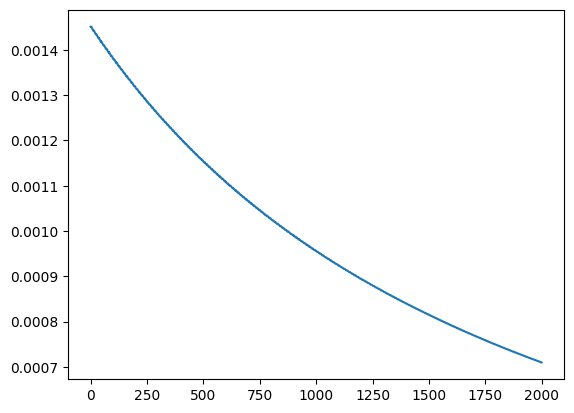

In [58]:
plt.plot(losses)

In [59]:
A2_final, _ = forward(X, W1, b1, W2, b2)
print("Predicted Probabilities:\n", np.round(A2_final, 4))
print("\nActual Labels:\n", y)
print("\nBinary Output (> 0.5):\n", (A2_final > 0.7).astype(int))

Predicted Probabilities:
 [[0.0012]
 [0.9998]
 [0.9998]
 [0.0012]]

Actual Labels:
 [[0]
 [1]
 [1]
 [0]]

Binary Output (> 0.5):
 [[0]
 [1]
 [1]
 [0]]


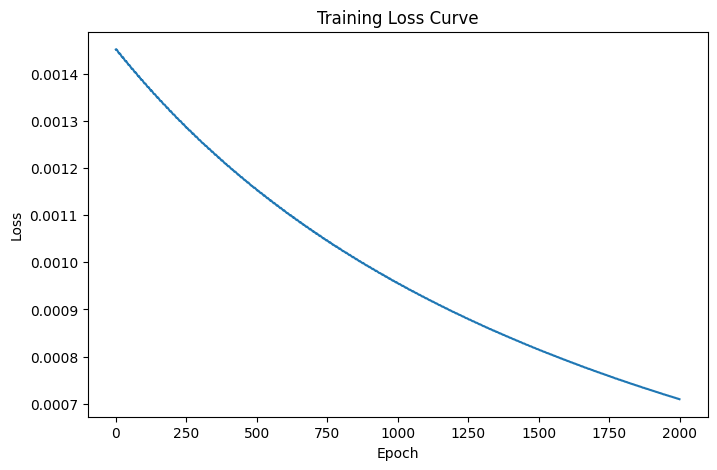

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.show()

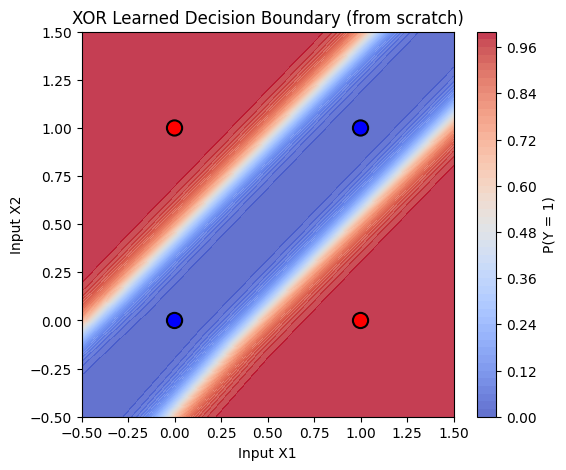

In [61]:
# ============================================================
# 7. Visualizing the Learned Decision Boundary
# ============================================================
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
preds, _ = forward(grid, W1, b1, W2, b2)
preds = preds.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, preds, levels=50, cmap="coolwarm", alpha=0.8)
plt.colorbar(label="P(Y = 1)")
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="bwr", edgecolors="k", s=120, linewidth=1.5)
plt.title("XOR Learned Decision Boundary (from scratch)")
plt.xlabel("Input X1")
plt.ylabel("Input X2")
plt.show()